# Modelos clásicos de ML sobre imágenes aplanadas

Este cuaderno muestra cómo abordar **MNIST** sin usar redes convolucionales.

La idea es:
1. Cargar el dataset.
2. Aplanar cada imagen de `28x28` a un vector de `784` características.
3. Entrenar dos modelos clásicos:
   - **Regresión logística** (usa una función sigmoide en clasificación lineal).
   - **Random Forest**.
4. Comparar resultados y visualizar errores.

Esto permite evidenciar que, aunque el problema puede abordarse con ML clásico, **la estructura espacial de la imagen se pierde** al aplanarla.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
keras.utils.set_random_seed(42)

In [2]:
# Cargar MNIST
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

print("Train images:", x_train_img.shape)
print("Test images: ", x_test_img.shape)
print("Train labels:", y_train.shape)
print("Test labels: ", y_test.shape)

Train images: (60000, 28, 28)
Test images:  (10000, 28, 28)
Train labels: (60000,)
Test labels:  (10000,)


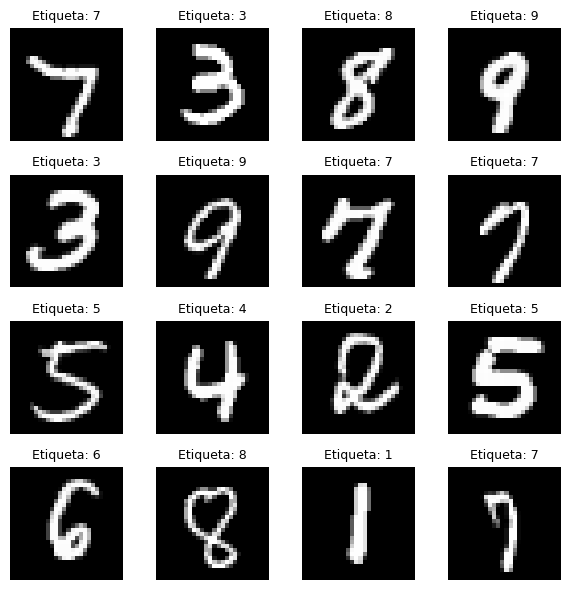

In [3]:
# Visualizar algunas imágenes
idx = np.random.choice(len(x_train_img), size=16, replace=False)

plt.figure(figsize=(6, 6))
for i, k in enumerate(idx):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(x_train_img[k], cmap="gray")
    plt.title(f"Etiqueta: {y_train[k]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Aplanar imágenes: 28x28 -> 784
x_train = x_train_img.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test_img.reshape(-1, 28 * 28).astype("float32") / 255.0

print("x_train:", x_train.shape)
print("x_test: ", x_test.shape)

x_train: (60000, 784)
x_test:  (10000, 784)


## Modelo 1: Regresión logística

Aunque el clasificador multiclase usa una generalización de la regresión logística,
la base conceptual sigue siendo la **función sigmoide** aplicada a clasificación lineal.


In [6]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=300,
        solver="lbfgs",
        random_state=42
    ))
])

logreg_model.fit(x_train, y_train)

y_pred_logreg = logreg_model.predict(x_test)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy - Logistic Regression: {acc_logreg:.4f}")

Accuracy - Logistic Regression: 0.9212


In [7]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.91      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



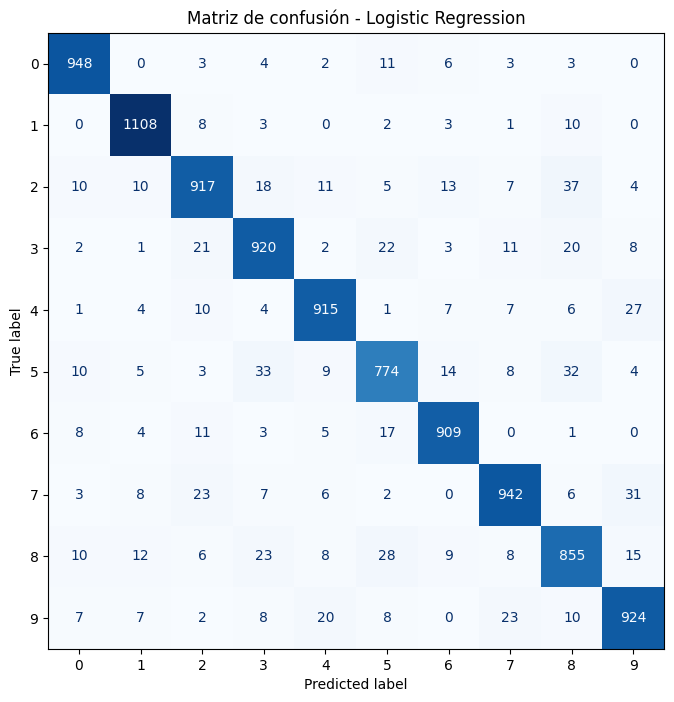

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logreg,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
plt.title("Matriz de confusión - Logistic Regression")
plt.show()

## Modelo 2: Random Forest

Ahora se usa un modelo no lineal basado en árboles.


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy - Random Forest: {acc_rf:.4f}")

Accuracy - Random Forest: 0.9692


In [10]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



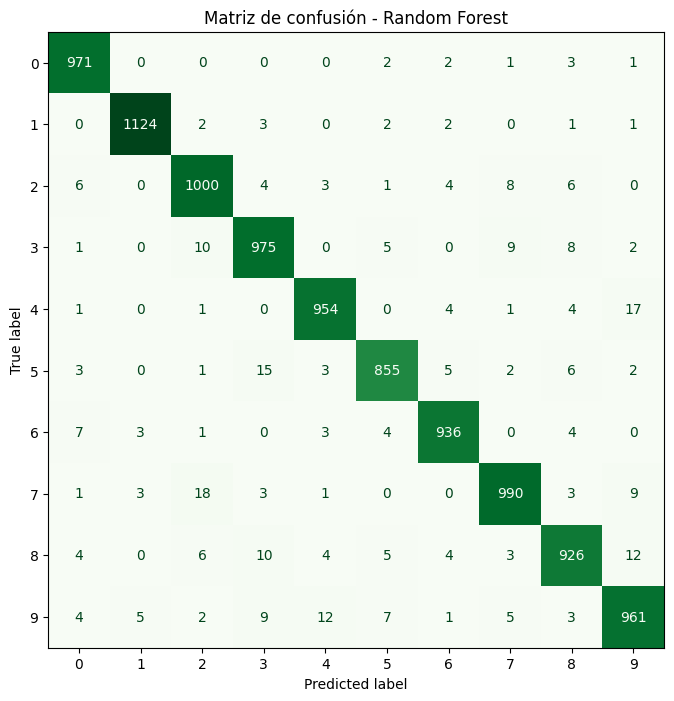

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Greens",
    ax=ax,
    colorbar=False
)
plt.title("Matriz de confusión - Random Forest")
plt.show()

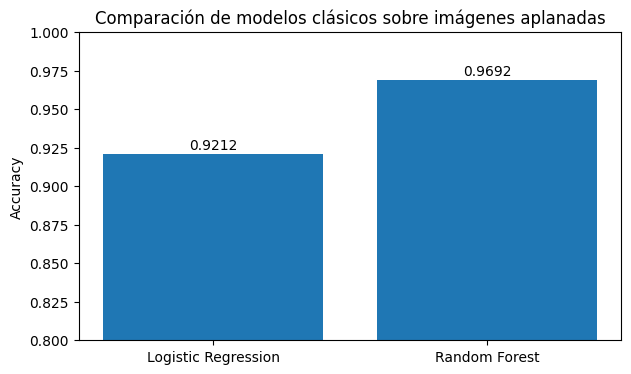

In [12]:
# Comparación simple
model_names = ["Logistic Regression", "Random Forest"]
accuracies = [acc_logreg, acc_rf]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, accuracies)
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Comparación de modelos clásicos sobre imágenes aplanadas")

for bar, value in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.003, f"{value:.4f}", ha="center")

plt.show()

## Ejemplos de aciertos y errores


In [13]:
def show_examples(images, y_true, y_pred, title, n=12, errors=False, seed=42):
    rng = np.random.default_rng(seed)

    if errors:
        idx = np.where(y_true != y_pred)[0]
    else:
        idx = np.where(y_true == y_pred)[0]

    n = min(n, len(idx))
    chosen = rng.choice(idx, size=n, replace=False)

    plt.figure(figsize=(10, 5))
    for i, k in enumerate(chosen):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[k], cmap="gray")
        plt.title(f"Real: {y_true[k]} / Pred: {y_pred[k]}", fontsize=9)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

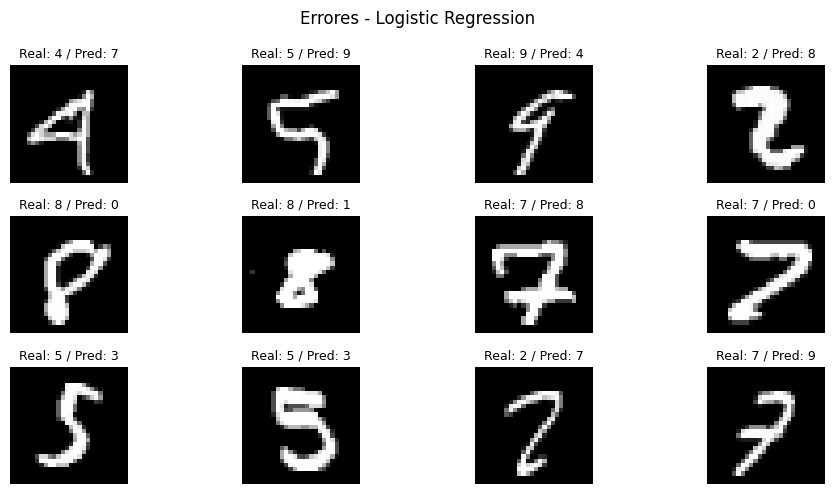

In [14]:
show_examples(
    x_test_img,
    y_test,
    y_pred_logreg,
    title="Errores - Logistic Regression",
    n=12,
    errors=True,
    seed=42
)

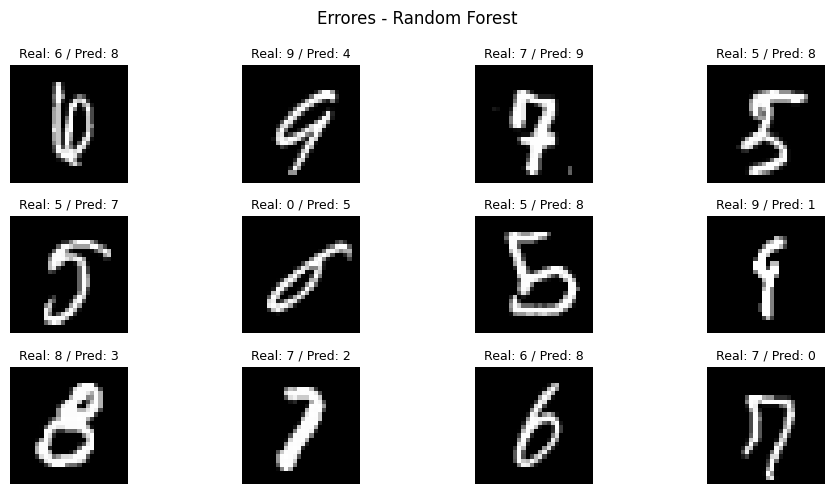

In [15]:
show_examples(
    x_test_img,
    y_test,
    y_pred_rf,
    title="Errores - Random Forest",
    n=12,
    errors=True,
    seed=42
)

## Comentario final

Con este experimento se observa que:

- El problema **sí puede** abordarse con modelos clásicos.
- Sin embargo, al aplanar la imagen, se pierde la **estructura espacial**.
- Por eso, para imágenes, las **CNN** suelen ser más adecuadas que un enfoque clásico sobre vectores planos.
